# Predict the pedestal using ESCAPE for ARC baseline scenario

In [7]:
import os
import numpy as np
import sys
from pathlib import Path
import pickle # to check which state attributes np.save can store
import netCDF4 as nc # OMFIT profile files are netCDF
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.ESCAPE.ESCAPE_solve import ESCAPE_solve
from helpers.load_equil import initialize_inputs
from examples.device_prediction.helper_functions import calc_pressure_profile
import time
from helpers.parse_equil import mhd_load
from helpers.parse_prof import kprof_load
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
# ---------------------- COMMON USER INPUTS ----------------------
alpha_crits = np.array([0.01])
nFC_x0s = np.array([1e15])
C_KBMs = np.array([0.3])
De_chie_etgs = np.array([0.1])
ncx_x0_ratios = np.array([15])

# Filepath to geqdsk equilibrium state and profiles
mhd_fp = 'geqdsk-ARCv3a'
ne_fp = 'ARC_ne.csv'
Te_fp = 'ARC_Te.csv'

# Overridable from the environment (see submit_scan.sh)
sc_model = os.environ.get('SC_MODEL', '3D')
sc_implementation = os.environ.get('SC_IMPLEMENTATION', 'firedrake')
ne_grad_bc_loc = os.environ.get('NE_GRAD_BC_LOC', 'inner')

output_dir = f'outputs/ARC_ESCAPE_{sc_model}{sc_implementation}{ne_grad_bc_loc}'
# ----------------------------------------------------------------

In [9]:
# Model setup
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Equilibria parameters
equil_num = 1
equil_list = None
mhd_loc = 'eqdsk'
kprof_loc = 'manual profs'
print(f'Number of equilibria to process: {equil_num}')

# Heating power
P_tot_e = ( 21.5 + 0.8 + 227 ) * 0.5 * 1e6 # table 4 of Hillesheim et al. 2026


def load_digitized_profile(filepath):
    """Load psi_N and profile data from a Web Plot Digitizer CSV export.

    Parameters
    ----------
    filepath : str or Path
        Path to an ARC_ne.csv / ARC_Te.csv file.

    Returns
    -------
    psi_N : ndarray
        Normalized poloidal flux, sorted ascending and clipped to [0, 1].
    profile : ndarray
        ne in 10^20 m^-3 or Te in keV, depending on the file.
    """
    data = np.loadtxt(filepath, delimiter=',')
    psi_N, profile = data[:, 0], data[:, 1]

    # Digitization noise can push the outermost point just past the separatrix
    psi_N = np.clip(psi_N, 0.0, 1.0)

    order = np.argsort(psi_N, kind='stable')
    psi_N, profile = psi_N[order], profile[order]

    # Clipping can collide two points at psi_N = 1; keep the outermost sample
    unique = np.append(np.diff(psi_N) > 0, True)
    return psi_N[unique], profile[unique]


psi_N_ne, ne_ref = load_digitized_profile(ne_fp)   # 10^20 m^-3
psi_N_Te, Te_ref = load_digitized_profile(Te_fp)   # keV

print(f'Loaded ne: {len(psi_N_ne)} points, psi_N in [{psi_N_ne[0]:.4f}, {psi_N_ne[-1]:.4f}], '
      f'{ne_ref[0]:.2f} -> {ne_ref[-1]:.2f} x10^20 m^-3')
print(f'Loaded Te: {len(psi_N_Te)} points, psi_N in [{psi_N_Te[0]:.4f}, {psi_N_Te[-1]:.4f}], '
      f'{Te_ref[0]:.2f} -> {Te_ref[-1]:.2f} keV')

kprof_params = {
    'n_e': ne_ref * 1e20,   # 10^20 m^-3 -> m^-3
    'T_e': Te_ref,          # keV
    'psin_ne': psi_N_ne,
    'psin_Te': psi_N_Te,
}


def load_equilibrium(mhd_fp, mhd_loc):
    """Build the ESCAPE_state inputs for one g-file.

    Returns
    -------
    equil_params : dict
        read_eqdsk dictionary of the g-file (psirz, fpol, pres, ip, rzout, ...),
        which is what ESCAPE_state.set_equil_params consumes.
    """
    equil_params = mhd_load(None, mhd_loc, mhd_fp)
    return equil_params


def state_to_dict(state):
    """Picklable snapshot of an ESCAPE state's attributes, for np.save.

    The state object itself can't be pickled: it holds the juliacall EPEDNN
    model and (after a Firedrake solve) Firedrake meshes/Functions. Those
    attributes are left out and their names recorded under '_not_saved'.
    """
    saved, not_saved = {}, []
    for name, val in vars(state).items():
        try:
            pickle.dumps(val)
        except Exception:
            not_saved.append(name)
        else:
            saved[name] = val
    saved['_not_saved'] = not_saved
    return saved


# ESCAPE parameters
ESCAPE_tol_max = 1e-5
ESCAPE_iter_max = 5
out_dir = output_dir
ne_x0 = None, # m^-3, electron density at the separatrix (boundary condition, default is to use from profiles)        
quasineutral_flag = True
T_rat_flag = True # True if using a temperature ratio between ions and electrons, False if doing something else
T_rat = 1
pol_norm = False # True for when the poloidal flux is not normalized by 2pi. COCOS 7 convention is pol_norm=False, so poloidal flux is normalized by 2pi
species = 'D' # species of ions, currently supporting: D, D-T
regime_flag = 'PT H-mode' # regime of the plasma, currently supporting: 'PT H-mode', 'NT'
verbose_ESCAPE = False

# Saarelma-Connor initialization parameters
sc_params = {
    'psi_N_inner_boundary': 0.85, # normalized poloidal flux at the inner boundary (boundary condition); overridden by find_inner_boundary if nFC_threshold or nCX_threshold is set
    'nFC_threshold': None, # fraction of nFC at the separatrix below which the inner boundary is placed (None to disable)
    'nCX_threshold': None, # fraction of nCX at the separatrix below which the inner boundary is placed (None to disable)
    'x_method': 'radas', # method to use for the cross-section rates, currently supporting: 'adas', 'radas'
    'verbose': False,
    'model': sc_model,
    'implementation': sc_implementation,
}

# Saarelma-Connor (SC) shared solver parameters
sc_params.update({
    'x_res':40,
    'ne_grad_bc_loc':ne_grad_bc_loc,
    'picard_max_it':50,
    'picard_rtol':1e-6,
    'picard_relax':1.0,
    'reuse_setup':False,
})

# SC scipy specific
sc_params.update({
    'bvp_tol':1e-6,
    'bvp_max_nodes':5000,
})

# SC firedrake specific
sc_params.update({
    'fe_degree':2, # firedrake specific
    'grad_bc_tol':1e-8,
    'grad_bc_max_it':25,
    'grad_bc_seed':None,
    'linear_solver':"lu",
    'ksp_rtol':1e-8,
    'ksp_max_it':200,
})

# SC 3D specific
sc_params.update({
    'nCX_ic':"scale nFC", # 'scale nFC' or 'solve' or 'state'
    'nFC_ic':"solve",
    'neutrals_treatment':"fem", # only for firedrake (FEM)
    'n_neutral_sub':4001, # only for firedrake (FEM)
})

# SC 1D specific
sc_params.update({
    'eq6_form':"complete",
    'first_step':"auto",
})

# EPEDNN parameters
epednn_params = {
    'epednn_model': 'EPED1', # 'EPED1' or 'EPED_SPARC'
    'pres_gfile': False, # use pressure from kprofs
}


import itertools

# ne_x0s = [None, 1e20, 2e20] # m^-3, manually specify outer bc for electron density
ne_x0s = [None] # m^-3, manually specify outer bc for electron density

scan_total = len(alpha_crits) * len(C_KBMs) * len(De_chie_etgs) * len(nFC_x0s) * len(ncx_x0_ratios) * len(ne_x0s)
print(f'Total number of scans: {scan_total}*{equil_num}')

Z_eff = 1.52 # https://www.cambridge.org/core/journals/journal-of-plasma-physics/article/overview-of-the-physics-basis-for-the-arc-fusion-power-plant/B472B3A64EF71DA1899B9EFB65D7C390
Z_i = 1

# ESCAPE_state inputs, plus the same profiles in calc_pressure_profile form
# so out_dict['profiles'] and the experimental pedestal pressure match them.
equil_params = load_equilibrium(mhd_fp, mhd_loc)


Number of equilibria to process: 1
Loaded ne: 79 points, psi_N in [0.0000, 1.0000], 3.19 -> 0.86 x10^20 m^-3
Loaded Te: 84 points, psi_N in [0.0000, 1.0000], 23.58 -> 0.20 keV
Total number of scans: 1*1


(0.0, 25.0)

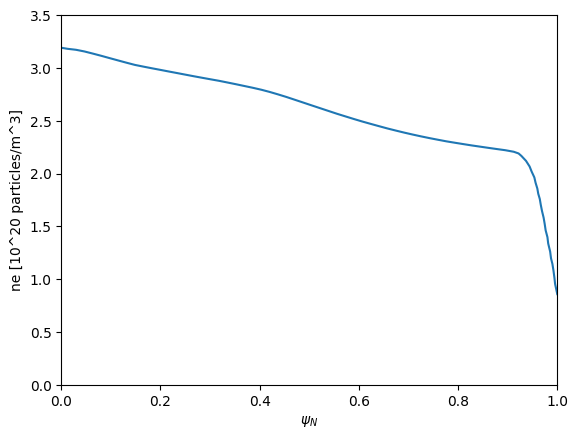

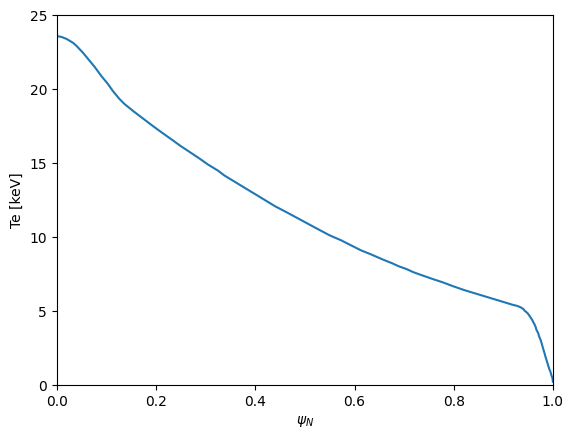

In [10]:
fig,ax = plt.subplots()
ax.plot(kprof_params['psin_ne'], kprof_params['n_e'] / 1e20, label='ne')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('ne [10^20 particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(kprof_params['psin_Te'], kprof_params['T_e'], label='Te')
ax1.set_xlabel(r'$\psi_N$')
ax1.set_ylabel('Te [keV]')

ax.set_xlim(0.0, 1)
ax.set_ylim(0, 3.5)
ax1.set_xlim(0.0, 1)
ax1.set_ylim(0, 25)


In [11]:
#-------------------------- Model run --------------------------# 
j=0
for ne_x0 in ne_x0s:
    i=0
    for combo in itertools.product(alpha_crits, C_KBMs, De_chie_etgs, nFC_x0s, ncx_x0_ratios):
        free_params = {
            'alpha_crit': combo[0],
            'C_KBM': combo[1],
            'De_chie_etg': combo[2],
            'nFC_x0': combo[3],
            'ncx_x0_ratio': combo[4]
        }
        sc_params['free_params'] = free_params

        # try:
        t0 = time.perf_counter()
        state = ESCAPE_solve(
            sc_params,
            epednn_params,
            Z_i = Z_i, # Z of ions
            Z_eff = Z_eff, 
            P_tot_e = P_tot_e, # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
            ne_x0 = ne_x0, # m^-3, electron density at the separatrix (boundary condition, default is to use from profiles)        
            equil_params = equil_params, # dictionary of required equilibrium parameters
            kprof_params = kprof_params, # dictionary of required kinetic profile (density, temperature) parameters
            quasineutral_flag = quasineutral_flag,
            T_rat_flag = T_rat_flag, # True if using a temperature ratio between ions and electrons, False if doing something else
            T_rat = T_rat,
            pol_norm = pol_norm, # True for when the poloidal flux is not normalized by 2pi. COCOS 7 convention is pol_norm=False, so poloidal flux is normalized by 2pi
            species = species, # species of ions, currently supporting: D, D-T
            regime_flag = regime_flag, # regime of the plasma, currently supporting: 'PT H-mode', 'NT'
            ESCAPE_iter_max = ESCAPE_iter_max, 
            ESCAPE_tol_max = ESCAPE_tol_max,
            out_dir = out_dir, # directory to output files
            verbose = verbose_ESCAPE,
        )
        t1 = time.perf_counter()

        # Save model output
        out_dict = {
            'mhd_fp': mhd_fp,
            'profiles': kprof_params, # experimental profiles
            'free_params': free_params,
            'Zeff': Z_eff,
            'P_tot_e': P_tot_e,
            'i': i,
            'state': state_to_dict(state), # picklable ESCAPE state attributes
            'ESCAPE_runtime': t1-t0,
        }
        np.save(out_dir + '/out_dict.npy', out_dict)
        # except Exception as e:
            # out_dict = {'failed': True, 'free_params': free_params, 'error': str(e)}
            # np.save(out_dir + '/failed.npy', out_dict)

        if i%50 == 0:
            print(f'Scan {i+1} of {scan_total} completed')
        i+=1
    j+=1

Initial state built.
Setting up EPEDNN...
One-time EPEDNN setup was successful.
------------------------------------------------
ESCAPE Loop Iter 0
solve_scmodel(model='3D', implementation='firedrake'): not using bvp_max_nodes (only for the other implementation), bvp_tol (only for the other implementation), eq6_form (only for model='1D'), first_step (only for model='1D'), nCX_threshold (not a solver argument), nFC_threshold (not a solver argument), psi_N_inner_boundary (not a solver argument), x_method (not a solver argument)
betan: [1.57120859]
------------------------------------------------
ESCAPE Loop Iter 1
betan: [1.41458059]
Normalized pedestal pressure height and width tolerance: 0.23583816182026413
------------------------------------------------
ESCAPE Loop Iter 2


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/ESCAPE/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/ESCAPE/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


betan: [1.41232823]
Normalized pedestal pressure height and width tolerance: 0.05632857030324728
------------------------------------------------
ESCAPE Loop Iter 3
betan: [1.40799542]
Normalized pedestal pressure height and width tolerance: 0.01873035405156797
------------------------------------------------
ESCAPE Loop Iter 4


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/ESCAPE/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/ESCAPE/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/ESCAPE/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


betan: [1.40717019]
Normalized pedestal pressure height and width tolerance: 0.00474713375397115
Scan 1 of 1 completed


In [12]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(kprof_params)
iter_files = sorted(Path(out_dir).glob('ne_and_Te_iter_*.npy'),
                    key=lambda p: int(p.stem.rsplit('_', 1)[-1]))  # numeric sort, so iter_10 comes after iter_9
last_iter = np.load(iter_files[-1], allow_pickle=True).item()
ped_wid = last_iter['pedestal_width']
ped_h_out = last_iter['pedestal_height']
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal heightprediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')


Pressure formula: 2*ne*Te
EPEDNN ped_top at psi_N = 1 - ped_wid = 0.968188
Profile p(psi_ped_top) = 194.296 kPa  (0.1943 MPa)
EPEDNN ped_h_out       = 96.676 kPa  (0.0967 MPa)
Accuracy of EPEDNN pedestal heightprediction: 100.98%


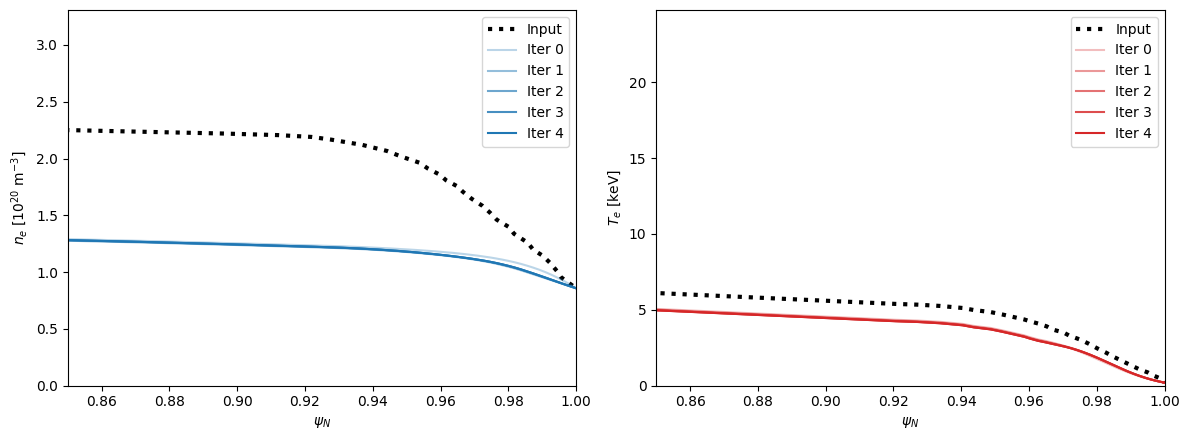

In [14]:
# n_e and T_e profiles per ESCAPE iteration (alpha 0.3 -> 1), input profiles dotted
iter_files = sorted(Path(out_dir).glob('ne_and_Te_iter_*.npy'),
                    key=lambda p: int(p.stem.rsplit('_', 1)[-1]))  # numeric sort, so iter_10 comes after iter_9
alphas = np.linspace(0.3, 1.0, len(iter_files))

fig, (ax_ne, ax_Te) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_ne.plot(kprof_params['psin_ne'], kprof_params['n_e'] / 1e20, 'k:', lw=3, label='Input')
ax_Te.plot(kprof_params['psin_Te'], kprof_params['T_e'], 'k:', lw=3, label='Input')

for f, alpha in zip(iter_files, alphas):
    it = np.load(f, allow_pickle=True).item()
    label = f"Iter {f.stem.rsplit('_', 1)[-1]}"
    ax_ne.plot(it['psi_ne_eval'], np.asarray(it['n_e']) / 1e20, color='C0', alpha=alpha, label=label)
    ax_Te.plot(it['psi_Te_eval'], it['T_e'], color='C3', alpha=alpha, label=label)

ax_ne.set_xlabel(r'$\psi_N$')
ax_ne.set_ylabel(r'$n_e$ [$10^{20}$ m$^{-3}$]')
ax_Te.set_xlabel(r'$\psi_N$')
ax_Te.set_ylabel(r'$T_e$ [keV]')
for ax in (ax_ne, ax_Te):
    ax.set_xlim(0.85, 1.0)
    ax.set_ylim(bottom=0)
    ax.legend()
fig.tight_layout()